# Lab 3: Clustering Analysis Using K-Means and K-Medoids
Student: [Your Name]

Course: MSCS-634 Advanced Big Data and Data Mining


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

wine = load_wine(); X, y = wine.data, wine.target
display(pd.DataFrame(X, columns=wine.feature_names).describe().T)
display(pd.Series(y).value_counts().sort_index().rename(index=dict(enumerate(wine.target_names))).to_frame("count"))
X_scaled = StandardScaler().fit_transform(X)


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


,count
class_0,59
class_1,71
class_2,48


In [2]:
class FallbackKMedoids:
    def __init__(self, n_clusters=3, random_state=42, max_iter=100):
        self.n_clusters, self.random_state, self.max_iter = n_clusters, random_state, max_iter
    def fit_predict(self, X):
        from sklearn.metrics import pairwise_distances
        distances = pairwise_distances(X)
        rng = np.random.RandomState(self.random_state)
        medoids = rng.choice(len(X), self.n_clusters, replace=False)
        for _ in range(self.max_iter):
            labels = distances[:, medoids].argmin(axis=1)
            updated = medoids.copy()
            for group in range(self.n_clusters):
                members = np.where(labels == group)[0]
                if len(members): updated[group] = members[np.argmin(distances[np.ix_(members, members)].sum(axis=1))]
            if np.array_equal(updated, medoids): break
            medoids = updated
        self.medoid_indices_ = medoids
        self.labels_ = distances[:, medoids].argmin(axis=1)
        return self.labels_

kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
kmeans_labels = kmeans.fit_predict(X_scaled)
try:
    from sklearn_extra.cluster import KMedoids
    kmedoids = KMedoids(n_clusters=3, init="k-medoids++", random_state=42, method="alternate")
    kmedoids_labels = kmedoids.fit_predict(X_scaled)
    print("K-Medoids implementation: scikit-learn-extra")
except (ImportError, ValueError):
    kmedoids = FallbackKMedoids(n_clusters=3, random_state=42)
    kmedoids_labels = kmedoids.fit_predict(X_scaled)
    print("K-Medoids implementation: compatible local fallback")

metrics = pd.DataFrame([
 {"algorithm":"K-Means", "silhouette_score":silhouette_score(X_scaled,kmeans_labels), "adjusted_rand_index":adjusted_rand_score(y,kmeans_labels)},
 {"algorithm":"K-Medoids", "silhouette_score":silhouette_score(X_scaled,kmedoids_labels), "adjusted_rand_index":adjusted_rand_score(y,kmedoids_labels)}
])
display(metrics)


K-Medoids implementation: compatible local fallback


,algorithm,silhouette_score,adjusted_rand_index
0,K-Means,0.284859,0.897495
1,K-Medoids,0.154764,0.341266


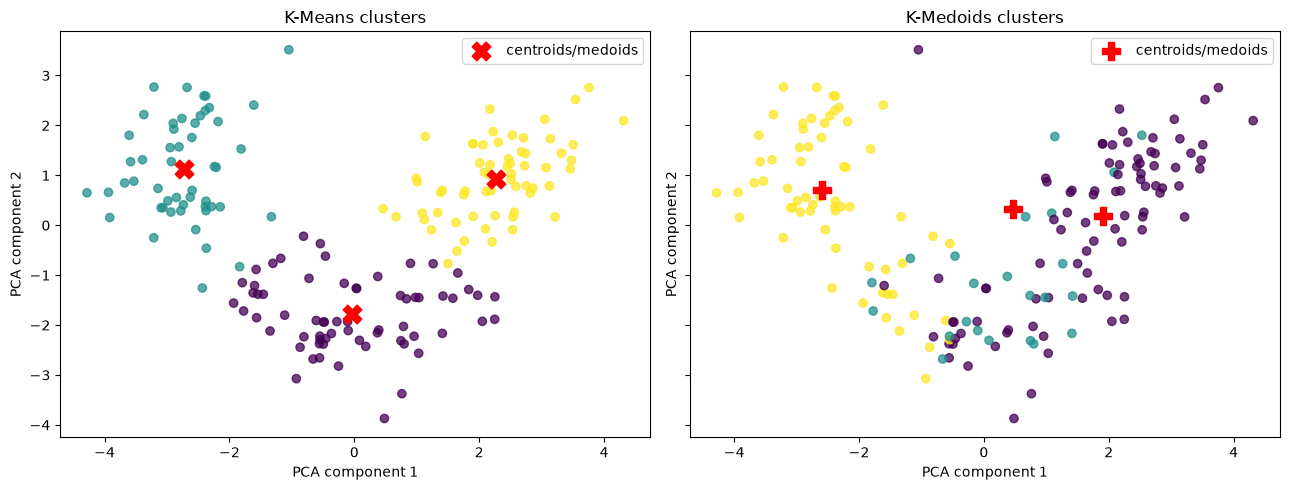

In [3]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
centers_pca = pca.transform(kmeans.cluster_centers_)
medoids_pca = X_pca[kmedoids.medoid_indices_]
fig, axes = plt.subplots(1,2,figsize=(13,5),sharex=True,sharey=True)
for ax, labels, title, reps, mark in [
 (axes[0], kmeans_labels, "K-Means clusters", centers_pca, "X"),
 (axes[1], kmedoids_labels, "K-Medoids clusters", medoids_pca, "P")]:
    ax.scatter(X_pca[:,0],X_pca[:,1],c=labels,cmap="viridis",alpha=.75)
    ax.scatter(reps[:,0],reps[:,1],c="red",s=180,marker=mark,label="centroids/medoids")
    ax.set(title=title,xlabel="PCA component 1",ylabel="PCA component 2"); ax.legend()
plt.tight_layout(); plt.show()


## Comparison
Silhouette Score measures cohesion and separation without the true labels. ARI measures agreement with the Wine classes. K-Means is efficient for compact, roughly spherical clusters and uses means as representatives. K-Medoids uses actual observations as representatives and is more robust to outliers, but generally costs more to compute.
